In [99]:
import numpy as np
import pandas as pd

df = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by=['indicator', 'date'], inplace=True)

# Limit to the last 100 unique dates
latest_dates = df['date'].drop_duplicates().sort_values().tail(100)
df = df[df['date'].isin(latest_dates)]

df[df['indicator'] == '146.71.50.198']

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
108521,818860012482918321,2025-02-23,146.71.50.198,0,6,True,23,2,0
108780,818860012482918321,2025-02-24,146.71.50.198,0,0,False,24,2,0
109039,818860012482918321,2025-02-25,146.71.50.198,0,1,False,25,2,0
109298,818860012482918321,2025-02-26,146.71.50.198,0,2,False,26,2,0
109557,818860012482918321,2025-02-27,146.71.50.198,0,3,False,27,2,0
...,...,...,...,...,...,...,...,...,...
133126,818860012482918321,2025-05-29,146.71.50.198,0,3,False,29,5,0
133385,818860012482918321,2025-05-30,146.71.50.198,0,4,False,30,5,0
133644,818860012482918321,2025-05-31,146.71.50.198,0,5,True,31,5,0
133903,818860012482918321,2025-06-01,146.71.50.198,0,6,True,1,6,0


In [100]:
# Function to extract features per indicator
def extract_time_series_features(group):
    series = group['seen'].values
    dates = group['date'].values

    indices = np.where(series == 1)[0]
    if len(indices) == 0:
        return pd.Series({
            'last_seen': len(series),
            'freq_7': 0,
            'freq_30': 0,
            'avg_gap': len(series),
            'burstiness': 0,
            'label_7': 0,
            'label_14': 0,
            'label_30': 0
        })

    last_seen = len(series) - 1 - indices[-1] # Number of days since the IP was last seen. Recent = low value. Captures recency.
    freq_7 = np.sum(series[-7:]) # Count of days seen in the last 7 days. Measures short-term activity.
    freq_30 = np.sum(series[-30:]) # Count of days seen in the last 30 days. Measures medium-term activity.
    gaps = np.diff(indices)
    avg_gap = np.mean(gaps) if len(gaps) > 0 else len(series) # Average time (in days) between two consecutive sightings. Shows periodicity.
    burstiness = (np.std(gaps) - avg_gap) / (np.std(gaps) + avg_gap) if len(gaps) > 1 else 0 # Measures how irregular or volatile the sightings are. Based on standard deviation of gaps: Ranges from -1 (very regular) to +1 (very bursty).
    label_7 = 1 if np.any(series[-7:]) else 0
    label_14 = 1 if np.any(series[-14:]) else 0
    label_30 = 1 if np.any(series[-30:]) else 0

    return pd.Series({
        'last_seen': last_seen,
        'freq_7': freq_7,
        'freq_30': freq_30,
        'avg_gap': avg_gap,
        'burstiness': burstiness,
        'label_7': label_7,
        'label_14': label_14,
        'label_30': label_30
    })

# Apply to each indicator group
features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_21672\1570248052.py:41: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [101]:
df[df['date'] == '2025-05-30']

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
133546,818860012482918321,2025-05-30,102.129.153.158,0,4,False,30,5,0
133529,818860012482918321,2025-05-30,102.129.153.43,0,4,False,30,5,0
133397,818860012482918321,2025-05-30,102.129.153.71,0,4,False,30,5,0
133547,818860012482918321,2025-05-30,102.165.16.161,0,4,False,30,5,0
133614,818860012482918321,2025-05-30,103.147.185.248,0,4,False,30,5,0
...,...,...,...,...,...,...,...,...,...
133496,818860012482918321,2025-05-30,international.standardbank.com/,0,4,False,30,5,0
133574,818860012482918321,2025-05-30,pub.marq.com/,0,4,False,30,5,0
133524,818860012482918321,2025-05-30,realinvestmentadvice.com/,9,4,False,30,5,1
133510,818860012482918321,2025-05-30,www.emergencylighting.com/,0,4,False,30,5,0


In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lifelines import WeibullAFTFitter
from scipy.stats import expon
import numpy as np

# Copy features into a separate DataFrame for modeling
df_pred = features_df.copy()

# Define features and labels
X = df_pred[['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']]
y_7 = df_pred['label_7']
y_14 = df_pred['label_14']
y_30 = df_pred['label_30']

# Helper functions
def train_predict(model_cls, X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([('scaler', StandardScaler()), ('clf', model_cls())])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

def train_gbt(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = GradientBoostingClassifier()
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

# Logistic Regression Predictions
df_pred['logistic_7'] = train_predict(LogisticRegression, X, y_7)
df_pred['logistic_14'] = train_predict(LogisticRegression, X, y_14)
df_pred['logistic_30'] = train_predict(LogisticRegression, X, y_30)

# Gradient Boosted Tree Predictions
df_pred['gbt_7'] = train_gbt(X, y_7)
df_pred['gbt_14'] = train_gbt(X, y_14)
df_pred['gbt_30'] = train_gbt(X, y_30)

# Exponential Model (Poisson-based) P(\text{seen in } t \text{ days}) = 1 - e^{-λt}, \quad \text{where } λ = \frac{\text{freq_30}}{30}
rate = (df_pred['freq_30'] / 30).clip(lower=1e-6)
df_pred['exp_7'] = 1 - np.exp(-rate * 7)
df_pred['exp_14'] = 1 - np.exp(-rate * 14)
df_pred['exp_30'] = 1 - np.exp(-rate * 30)

# Weibull AFT Model A survival model that predicts time until next sighting.
aft_df = X.copy()
aft_df['duration'] = df_pred['avg_gap']
aft_df['event'] = y_7

aft = WeibullAFTFitter()
aft.fit(aft_df, duration_col='duration', event_col='event')

# Predict survival function at 1, 7, 14, 30 days
surv_func = aft.predict_survival_function(aft_df, times=[1, 7, 14, 30])
df_pred['weibull_today'] = 1 - surv_func.loc[1].values
df_pred['weibull_7'] = 1 - surv_func.loc[7].values
df_pred['weibull_14'] = 1 - surv_func.loc[14].values
df_pred['weibull_30'] = 1 - surv_func.loc[30].values

# Today's forecast
df_pred['exp_today'] = 1 - np.exp(-rate * 1)
df_pred['logistic_today'] = train_predict(LogisticRegression, X, y_7)
df_pred['gbt_today'] = train_gbt(X, y_7)

# Merge in actual "seen" value for today's date
latest_date = df['date'].max()
today_seen = df[df['date'] == latest_date][['indicator', 'seen']].rename(columns={'seen': 'seen_today'})
df_pred = df_pred.merge(today_seen, on='indicator', how='left')

# Final output
output = df_pred[[
    'indicator', 'seen_today', 'last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness',
    'exp_today', 'exp_7', 'exp_14', 'exp_30',
    'weibull_today', 'weibull_7', 'weibull_14', 'weibull_30',
    'logistic_today', 'logistic_7', 'logistic_14', 'logistic_30',
    'gbt_today', 'gbt_7', 'gbt_14', 'gbt_30'
]]

display(output)


,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,12.0,0.0,1.0,37.500000,-0.388889,3.278390e-02,0.208110,0.372911,...,7.784023e-03,8.561362e-02,0.036388,0.036388,0.626192,0.956860,0.000014,0.000014,0.999978,0.999983
1,102.129.153.43,0,17.0,0.0,1.0,36.500000,-0.403846,3.278390e-02,0.208110,0.372911,...,1.274298e-03,1.449818e-02,0.027500,0.027500,0.471444,0.925805,0.000014,0.000014,0.000022,0.999983
2,102.129.153.71,0,4.0,1.0,2.0,18.800000,-0.223835,6.449301e-02,0.372911,0.606759,...,8.309935e-01,1.000000e+00,0.831613,0.831613,0.952924,0.990729,0.999971,0.999971,0.999978,0.999983
3,102.165.16.161,0,53.0,0.0,0.0,6.000000,-0.381966,9.999995e-07,0.000007,0.000014,...,2.540115e-08,2.909286e-07,0.004464,0.004464,0.006188,0.106871,0.000014,0.000014,0.000022,0.000027
4,103.147.185.248,0,11.0,0.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,...,2.676791e-05,3.065398e-04,0.061094,0.061094,0.746470,0.939769,0.000014,0.000014,0.999978,0.999983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254,international.standardbank.com/,0,100.0,0.0,0.0,100.000000,0.000000,9.999995e-07,0.000007,0.000014,...,0.000000e+00,0.000000e+00,0.000528,0.000528,0.000035,0.000278,0.000014,0.000014,0.000022,0.000027
255,pub.marq.com/,0,19.0,0.0,1.0,9.600000,0.122880,3.278390e-02,0.208110,0.372911,...,1.056625e-02,1.145533e-01,0.072355,0.072355,0.350500,0.857531,0.000014,0.000014,0.000022,0.999983
256,realinvestmentadvice.com/,0,3.0,1.0,2.0,8.272727,-0.015986,6.449301e-02,0.372911,0.606759,...,9.996802e-01,1.000000e+00,0.890103,0.890103,0.954063,0.990003,0.999971,0.999971,0.999978,0.999983
257,www.emergencylighting.com/,0,12.0,0.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,...,1.828218e-05,2.093725e-04,0.058128,0.058128,0.722133,0.932714,0.000014,0.000014,0.999978,0.999983


In [103]:
output.drop(columns=['indicator'])

,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,exp_30,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,0,12.0,0.0,1.0,37.500000,-0.388889,3.278390e-02,0.208110,0.372911,0.632121,...,7.784023e-03,8.561362e-02,0.036388,0.036388,0.626192,0.956860,0.000014,0.000014,0.999978,0.999983
1,0,17.0,0.0,1.0,36.500000,-0.403846,3.278390e-02,0.208110,0.372911,0.632121,...,1.274298e-03,1.449818e-02,0.027500,0.027500,0.471444,0.925805,0.000014,0.000014,0.000022,0.999983
2,0,4.0,1.0,2.0,18.800000,-0.223835,6.449301e-02,0.372911,0.606759,0.864665,...,8.309935e-01,1.000000e+00,0.831613,0.831613,0.952924,0.990729,0.999971,0.999971,0.999978,0.999983
3,0,53.0,0.0,0.0,6.000000,-0.381966,9.999995e-07,0.000007,0.000014,0.000030,...,2.540115e-08,2.909286e-07,0.004464,0.004464,0.006188,0.106871,0.000014,0.000014,0.000022,0.000027
4,0,11.0,0.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,0.632121,...,2.676791e-05,3.065398e-04,0.061094,0.061094,0.746470,0.939769,0.000014,0.000014,0.999978,0.999983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254,0,100.0,0.0,0.0,100.000000,0.000000,9.999995e-07,0.000007,0.000014,0.000030,...,0.000000e+00,0.000000e+00,0.000528,0.000528,0.000035,0.000278,0.000014,0.000014,0.000022,0.000027
255,0,19.0,0.0,1.0,9.600000,0.122880,3.278390e-02,0.208110,0.372911,0.632121,...,1.056625e-02,1.145533e-01,0.072355,0.072355,0.350500,0.857531,0.000014,0.000014,0.000022,0.999983
256,0,3.0,1.0,2.0,8.272727,-0.015986,6.449301e-02,0.372911,0.606759,0.864665,...,9.996802e-01,1.000000e+00,0.890103,0.890103,0.954063,0.990003,0.999971,0.999971,0.999978,0.999983
257,0,12.0,0.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,0.632121,...,1.828218e-05,2.093725e-04,0.058128,0.058128,0.722133,0.932714,0.000014,0.000014,0.999978,0.999983


In [104]:
output[output['indicator'] == '102.129.153.158']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,12.0,0.0,1.0,37.5,-0.388889,0.032784,0.20811,0.372911,...,0.007784,0.085614,0.036388,0.036388,0.626192,0.95686,0.000014,0.000014,0.999978,0.999983


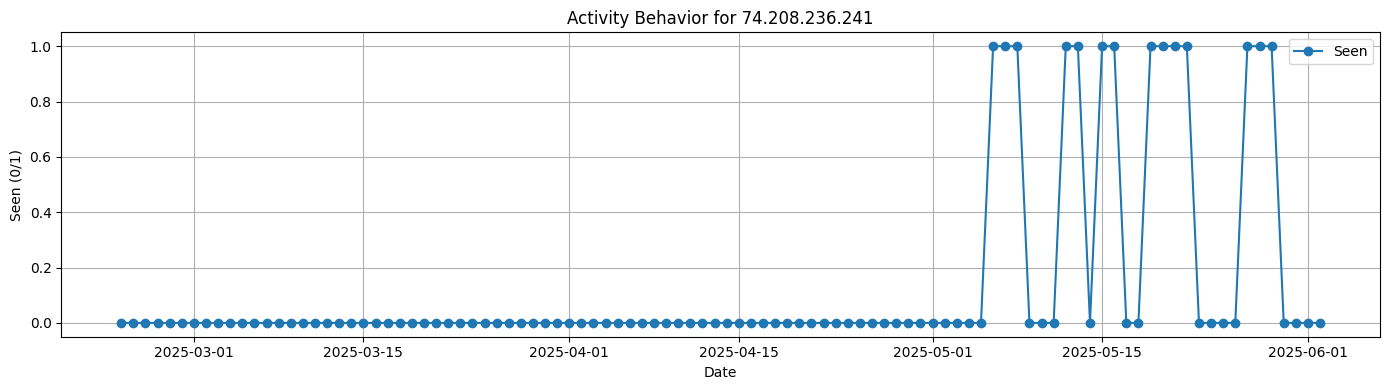

In [105]:
import matplotlib.pyplot as plt

indicator_id = '74.208.236.241'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [106]:
output[output['indicator'] == '113.96.236.11']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
20,113.96.236.11,0,74.0,0.0,0.0,1.75,-0.357033,9.999995e-07,0.000007,0.000014,...,1.303901e-11,1.493407e-10,0.001573,0.001573,0.000437,0.009691,0.000014,0.000014,0.000022,0.000027


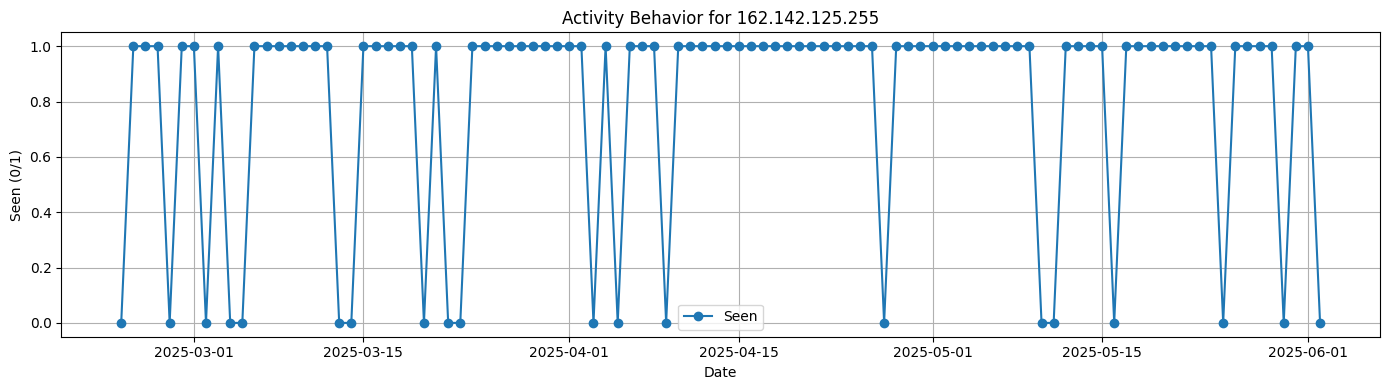

In [107]:
indicator_id = '162.142.125.255'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [108]:
df[(df['seen'] ==0) & (df['date'] == pd.Timestamp('2025-05-21'))]

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
131198,818860012482918321,2025-05-21,102.129.153.43,0,2,False,21,5,0
131066,818860012482918321,2025-05-21,102.129.153.71,0,2,False,21,5,0
131216,818860012482918321,2025-05-21,102.165.16.161,0,2,False,21,5,0
131283,818860012482918321,2025-05-21,103.147.185.248,0,2,False,21,5,0
131300,818860012482918321,2025-05-21,103.156.92.159,0,2,False,21,5,0
...,...,...,...,...,...,...,...,...,...
131275,818860012482918321,2025-05-21,93.123.109.231,0,2,False,21,5,0
131209,818860012482918321,2025-05-21,hcmiu.edu.vn/,0,2,False,21,5,0
131165,818860012482918321,2025-05-21,international.standardbank.com/,0,2,False,21,5,0
131243,818860012482918321,2025-05-21,pub.marq.com/,0,2,False,21,5,0


In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import expon
import numpy as np

#  Define features and labels ---
features = ['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']
X = output[features]

#  Rule-Based Binary Labels Using last_seen ---
output['rule_today'] = output['last_seen'].apply(lambda x: 1 if x == 0 else 0)
output['rule_7d'] = output['last_seen'].apply(lambda x: 1 if x <= 6 else 0)
output['rule_14d'] = output['last_seen'].apply(lambda x: 1 if x <= 13 else 0)
output['rule_30d'] = output['last_seen'].apply(lambda x: 1 if x <= 29 else 0)

y_today = output['rule_today']
y_7 = output['rule_7d']
y_14 = output['rule_14d']
y_30 = output['rule_30d']

#  Logistic Regression Model ---
def train_logistic_model(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression())
    ])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

output['prob_today'] = train_logistic_model(X, y_today)
output['prob_7d'] = train_logistic_model(X, y_7)
output['prob_14d'] = train_logistic_model(X, y_14)
output['prob_30d'] = train_logistic_model(X, y_30)

#  Ensemble Probabilities ---
output['ensemble_7d'] = (
    0.3 * output['prob_7d'].astype(float) +
    0.25 * output['gbt_7'] +
    0.25 * output['weibull_7'] +
    0.3 * output['exp_7']
)

output['ensemble_14d'] = (
    0.3 * output['prob_14d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25* output['weibull_14'] +
    0.3 * output['exp_14']
)

output['ensemble_30d'] = (
    0.3 * output['prob_30d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25 * output['weibull_30'] +
    0.3 * output['exp_30']
)

#  Confidence Tags ---
def classify_window(prob, freq_7, high_thresh, label):
    if prob >= high_thresh and freq_7 >= 2:
        return f"{label}: Highly likely"
    elif prob >= 0.07 and freq_7 >= 1:
        return f"{label}: Possibly active"
    else:
        return f"{label}: Low confidence"

# Compute confidence tags using raw probabilities (not formatted as strings)
output['confidence_today'] = output.apply(
    lambda row: classify_window(
        row['prob_today'],
        row['freq_7'], 0.6, 'Today'
    ), axis=1
)

output['confidence_7d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_7d'],
        row['freq_7'], 0.6, '7-Day'
    ), axis=1
)

output['confidence_14d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_14d'],
        row['freq_7'], 0.6, '14-Day'
    ), axis=1
)

output['confidence_30d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_30d'],
        row['freq_7'], 0.6, '30-Day'
    ), axis=1
)

#  Format Percentages ---
for col in ['prob_7d', 'prob_14d', 'prob_30d', 'ensemble_7d', 'ensemble_14d', 'ensemble_30d']:
    output[col] = np.clip(output[col].astype(float) * 100, 0, 100).round(2).astype(str) + '%'

#  Format Today prob ---
output['prob_today'] = np.clip(output['prob_today'].astype(float) * 100, 0, 100).round(2).astype(str) + '%'

#  Final Output ---
production_output = output[[
    'indicator', 'seen_today', 'freq_7', 'freq_30',
    'prob_today', 'confidence_today',
    'ensemble_7d', 'confidence_7d',
    'ensemble_14d', 'confidence_14d',
    'ensemble_30d', 'confidence_30d'
]].copy()

# --- Rename for display ---
production_output.rename(columns={
    'indicator': 'Indicator',
    'seen_today': 'Observed Today',
    'freq_7': 'Frequency (7d)',
    'freq_30': 'Frequency (30d)',
    'prob_today': 'Probability: Today',
    'confidence_today': 'Confidence: Today',
    'ensemble_7d': 'Probability: 7-Day',
    'confidence_7d': 'Confidence: 7-Day',
    'ensemble_14d': 'Probability: 14-Day',
    'confidence_14d': 'Confidence: 14-Day',
    'ensemble_30d': 'Probability: 30-Day',
    'confidence_30d': 'Confidence: 30-Day'
}, inplace=True)

display(production_output)



C:\Users\jaskew\AppData\Local\Temp\ipykernel_21672\3344784157.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\jaskew\AppData\Local\Temp\ipykernel_21672\3344784157.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
0,102.129.153.158,0,0.0,1.0,1.08%,Today: Low confidence,7.36%,7-Day: Low confidence,55.17%,14-Day: Low confidence,74.81%,30-Day: Low confidence
1,102.129.153.43,0,0.0,1.0,0.89%,Today: Low confidence,7.07%,7-Day: Low confidence,25.36%,14-Day: Low confidence,47.1%,30-Day: Low confidence
2,102.129.153.71,0,1.0,2.0,4.01%,Today: Low confidence,65.53%,7-Day: Possibly active,92.56%,14-Day: Possibly active,100.0%,30-Day: Possibly active
3,102.165.16.161,0,0.0,0.0,0.27%,Today: Low confidence,0.13%,7-Day: Low confidence,0.19%,14-Day: Low confidence,3.21%,30-Day: Low confidence
4,103.147.185.248,0,0.0,1.0,1.63%,Today: Low confidence,8.08%,7-Day: Low confidence,58.58%,14-Day: Low confidence,72.16%,30-Day: Low confidence
...,...,...,...,...,...,...,...,...,...,...,...,...
254,international.standardbank.com/,0,0.0,0.0,0.07%,Today: Low confidence,0.02%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.01%,30-Day: Low confidence
255,pub.marq.com/,0,0.0,1.0,1.34%,Today: Low confidence,8.44%,7-Day: Low confidence,21.97%,14-Day: Low confidence,47.55%,30-Day: Low confidence
256,realinvestmentadvice.com/,0,1.0,2.0,4.97%,Today: Low confidence,77.48%,7-Day: Possibly active,96.82%,14-Day: Possibly active,100.0%,30-Day: Possibly active
257,www.emergencylighting.com/,0,0.0,1.0,1.57%,Today: Low confidence,7.99%,7-Day: Low confidence,57.85%,14-Day: Low confidence,71.95%,30-Day: Low confidence


### Observed Indicator Activity Analysis

In [110]:
production_analysis_indicators = production_output[production_output['Observed Today'] == 1]
production_analysis_indicators

,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
14,104.21.48.1,1,7.0,30.0,59.12%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
15,104.21.54.132,1,3.0,25.0,5.28%,Today: Low confidence,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
17,104.21.76.17,1,1.0,1.0,6.12%,Today: Low confidence,57.01%,7-Day: Possibly active,65.63%,14-Day: Possibly active,74.29%,30-Day: Possibly active
103,196.251.71.232,1,2.0,3.0,11.52%,Today: Possibly active,94.98%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
106,196.251.87.59,1,3.0,4.0,21.45%,Today: Possibly active,98.2%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
159,31.177.76.32,1,2.0,2.0,13.59%,Today: Possibly active,91.09%,7-Day: Highly likely,97.95%,14-Day: Highly likely,100.0%,30-Day: Highly likely
160,31.177.80.32,1,2.0,2.0,13.59%,Today: Possibly active,91.09%,7-Day: Highly likely,97.95%,14-Day: Highly likely,100.0%,30-Day: Highly likely
162,34.160.111.145,1,7.0,19.0,87.6%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
250,93.123.109.230,1,2.0,4.0,9.47%,Today: Possibly active,98.1%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
258,www.shorturl.at/,1,4.0,16.0,25.71%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely


In [111]:
import os
import pandas as pd
from datetime import datetime, timedelta

# Base file path with placeholder for date
base_path = r"Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d{date}.csv"
#base_path = r"C:\Users\jaskew\Documents\project_repository\data\raw\ObservationDataFiles\htoc_opdiv_obs_d{date}.csv"
date_format = "%Y%m%d"

def get_file_paths(base_path, days=90):
    """ Generate file paths for the last `days` days using list comprehension. """
    today = datetime.utcnow()
    dates_to_pull = [(today - timedelta(days=i)).strftime(date_format) for i in range(days)]
    
    # Construct file paths
    file_paths = [base_path.format(date=dt) for dt in dates_to_pull]
    
    # Filter for existing files
    existing_files = [file_path for file_path in file_paths if os.path.exists(file_path)]
    
    if not existing_files:
        print("No files found for the specified date range.")
    else:
        print(f"Files to be loaded: {existing_files}")
    
    return existing_files

def load_observed_data(file_paths):
    """ Load and concatenate observed data from multiple files. """
    data_frames = []

    for file_path in file_paths:
        try:
            df = pd.read_csv(file_path)
            data_frames.append(df)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Concatenate data
    if data_frames:
        observed_data_df = pd.concat(data_frames, ignore_index=True)
        print(f"Loaded data from {len(data_frames)} files.")
    else:
        observed_data_df = pd.DataFrame()

    return observed_data_df

# Example Usage:
# Fetch file paths for the last 3 days
file_paths = get_file_paths(base_path, days=90)

# Load observed data
observed_data_df = load_observed_data(file_paths)



Files to be loaded: ['Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250602.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250601.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250531.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250530.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250529.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250528.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250527.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250526.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250525.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250524.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250523.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250522.csv', 'Z:/HTOC/Data_Analytics/Data/Op

In [112]:
# For each indicator in production_analysis_indicators, pull obs_date and OpDiv from observed_data_df
# Get the list of indicators
indicators = production_analysis_indicators['Indicator'].unique()

# Filter observed_data_df for those indicators and select relevant columns
indicator_obs = observed_data_df[observed_data_df['indicator'].isin(indicators)][['indicator', 'obs_date', 'OpDiv']]

display(indicator_obs)

,indicator,obs_date,OpDiv
77,196.251.87.59,2025-06-02,OS
78,196.251.87.59,2025-06-02,VA
79,196.251.87.59,2025-06-02,CDC
80,196.251.87.59,2025-06-02,IHS
81,196.251.87.59,2025-06-02,FDA
...,...,...,...
49735,104.21.54.132,2025-03-05,CDC
49933,34.160.111.145,2025-03-05,CDC
49934,34.160.111.145,2025-03-05,CMS
49935,34.160.111.145,2025-03-05,HHS


In [113]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Ensure obs_date is datetime and column names are consistent
if 'Indicator' in indicator_obs.columns:
    indicator_obs = indicator_obs.rename(columns={'Indicator': 'indicator'})

indicator_obs['obs_date'] = pd.to_datetime(indicator_obs['obs_date'], errors='coerce')

# Get unique indicators
indicators = indicator_obs['indicator'].unique()

for indicator in indicators:
    group = indicator_obs[indicator_obs['indicator'] == indicator]
    opdivs = group['OpDiv'].unique()
    opdiv_to_idx = {opdiv: i for i, opdiv in enumerate(opdivs)}

    fig = go.Figure()
    for opdiv in opdivs:
        opdiv_group = group[group['OpDiv'] == opdiv]
        if not opdiv_group.empty:
            y_val = opdiv_to_idx[opdiv]
            jitter = np.random.uniform(-0.2, 0.2, size=len(opdiv_group))
            fig.add_trace(go.Scatter(
                x=opdiv_group['obs_date'],
                y=[y_val + j for j in jitter],
                mode='markers+text',
                marker=dict(size=12, color=px.colors.qualitative.Plotly[y_val % 10], line=dict(width=1, color='black')),
                name=opdiv,
                text=opdiv_group['OpDiv'],
                textposition='top center',
                hovertemplate='OpDiv: %{text}<br>Date: %{x|%Y-%m-%d}<extra></extra>'
            ))

    fig.update_layout(
        title=f'All Observation Dates for {indicator}',
        yaxis=dict(
            tickmode='array',
            tickvals=list(opdiv_to_idx.values()),
            ticktext=list(opdiv_to_idx.keys()),
            title='OpDiv'
        ),
        xaxis_title='Observation Date',
        height=80 + 60 * len(opdivs),
        legend_title='OpDiv',
        margin=dict(l=40, r=40, t=40, b=40)
    )
    fig.show()


## Threat Actor Associations

In [117]:
THREAT_ACTORS = r'Z:\HTOC\Data_Analytics\Data\Observed_Tags\htoc_observed_indicator_tags.csv'

In [123]:
# Load threat actor tag data from the specified CSV file
threat_actor_tags = pd.read_csv(THREAT_ACTORS)
display(threat_actor_tags)

,indicator,type,tag,threat_category
0,003@tagmode-search.com,EmailAddress,Malspam,TECHNIQUE
1,0secure.ru,Host,Reconnaissance,TECHNIQUE
2,0secure.ru,Host,Phishing,MITRE_TECHNIQUE
3,1-you.njalla.no,Host,Malspam,TECHNIQUE
4,1-you.njalla.no,Host,CVE-2017-0199,VULNERABILITY
...,...,...,...,...
8967,zerocap.com,Host,SocGholish,MALWARE
8968,zerocap.com,Host,Ransomware/Ransomware-as-a-Service (RaaS),MALWARE TYPE
8969,zimbra@infinigi.com,EmailAddress,Health-ISAC,SOURCE
8970,zimbra@infinigi.com,EmailAddress,Phishing,MITRE_TECHNIQUE


In [126]:
matched_indicators = production_output['Indicator'].isin(threat_actor_tags['indicator'])
production_output_with_tags = production_output[matched_indicators]
# Merge in tags and threat categories from threat_actor_tags
production_output_with_tags = production_output_with_tags.merge(
    threat_actor_tags[['indicator', 'tag', 'threat_category']],
    left_on='Indicator',
    right_on='indicator',
    how='left'
)
display(production_output_with_tags)



,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day,indicator,tag,threat_category
0,102.129.153.158,0,0.0,1.0,1.08%,Today: Low confidence,7.36%,7-Day: Low confidence,55.17%,14-Day: Low confidence,74.81%,30-Day: Low confidence,102.129.153.158,Phishing,TECHNIQUE
1,102.129.153.158,0,0.0,1.0,1.08%,Today: Low confidence,7.36%,7-Day: Low confidence,55.17%,14-Day: Low confidence,74.81%,30-Day: Low confidence,102.129.153.158,Health-ISAC,SOURCE
2,102.129.153.158,0,0.0,1.0,1.08%,Today: Low confidence,7.36%,7-Day: Low confidence,55.17%,14-Day: Low confidence,74.81%,30-Day: Low confidence,102.129.153.158,Business Email Compromise (BEC),TECHNIQUE
3,102.129.153.43,0,0.0,1.0,0.89%,Today: Low confidence,7.07%,7-Day: Low confidence,25.36%,14-Day: Low confidence,47.1%,30-Day: Low confidence,102.129.153.43,Health-ISAC,SOURCE
4,102.129.153.43,0,0.0,1.0,0.89%,Today: Low confidence,7.07%,7-Day: Low confidence,25.36%,14-Day: Low confidence,47.1%,30-Day: Low confidence,102.129.153.43,Social Engineering,TECHNIQUE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,www.emergencylighting.com/,0,0.0,1.0,1.57%,Today: Low confidence,7.99%,7-Day: Low confidence,57.85%,14-Day: Low confidence,71.95%,30-Day: Low confidence,www.emergencylighting.com/,web injections,TECHNIQUE
344,www.emergencylighting.com/,0,0.0,1.0,1.57%,Today: Low confidence,7.99%,7-Day: Low confidence,57.85%,14-Day: Low confidence,71.95%,30-Day: Low confidence,www.emergencylighting.com/,Financial Sector,SECTOR
345,www.emergencylighting.com/,0,0.0,1.0,1.57%,Today: Low confidence,7.99%,7-Day: Low confidence,57.85%,14-Day: Low confidence,71.95%,30-Day: Low confidence,www.emergencylighting.com/,ColdFusion,VULNERABILITY
346,www.shorturl.at/,1,4.0,16.0,25.71%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely,www.shorturl.at/,Malspam,TECHNIQUE


In [127]:
production_output_with_tags[production_output_with_tags['tag'] == 'UNC5537']

,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day,indicator,tag,threat_category
8,102.165.16.161,0,0.0,0.0,0.27%,Today: Low confidence,0.13%,7-Day: Low confidence,0.19%,14-Day: Low confidence,3.21%,30-Day: Low confidence,102.165.16.161,UNC5537,THREAT ACTOR


# Condense tags for each indicator into a single row with lists of tags and threat categories
condensed = (
    output_tagged
    .groupby('Indicator')
    .agg({
        'Observed Today': 'first',
        'Frequency (7d)': 'first',
        'Frequency (30d)': 'first',
        'Probability: Today': 'first',
        'Confidence: Today': 'first',
        'Probability: 7-Day': 'first',
        'Confidence: 7-Day': 'first',
        'Probability: 14-Day': 'first',
        'Confidence: 14-Day': 'first',
        'Probability: 30-Day': 'first',
        'Confidence: 30-Day': 'first',
        'tag': lambda x: list(x.unique()),
        'threat_category': lambda x: list(x.dropna().unique())
    })
    .reset_index()
)